In [137]:
# Step 1: Imports and Data Load
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_absolute_error,accuracy_score, mean_squared_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression
import xgboost as xgb
import joblib
import warnings
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)
warnings.filterwarnings('ignore')

In [138]:
# Load the dataset (update path if needed)
df = pd.read_csv('../data/Original_Flight_Data.csv')
print("Shape of dataset (rows, columns):")
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nDataset info:")
df.info()

print("\nStatistical summary (numeric columns):")
display(df.describe())
print("Dataset loaded successfully!")

Shape of dataset (rows, columns):
Dataset shape: (9754, 51)

Column names:
['id', 'airline', 'origin', 'origin_code', 'destination', 'destination_code', 'route', 'aircraft_type', 'scheduled_depature_time', 'actual_depature_time', 'scheduled_arrival_time', 'actual_arrival_time', 'departure_delay_min', 'arrival_delay_min', 'is_diverted', 'is_cancelled', 'dep_has_rain', 'dep_has_thunderstorm', 'dep_low_visibility', 'dep_high_wind', 'arr_has_rain', 'arr_has_thunderstorm', 'arr_low_visibility', 'dep_is_monsoon_season', 'dep_date_only', 'is_sri_lankan_public_holiday', 'is_poya_day', 'is_festival_period', 'is_post_holiday', 'is_long_weekend', 'scheduled_departure_hour', 'scheduled_arrival_hour', 'scheduled_departure_day_of_week', 'scheduled_arrival_day_of_week', 'scheduled_is_weekend', 'scheduled_month', 'scheduled_is_peak_hour', 'scheduled_early_morning_departure', 'scheduled_late_night_departure', 'scheduled_flight_duration_min', 'delay_ratio', 'is_short_haul', 'route_avg_delay', 'route_del

,id,airline,origin,origin_code,destination,destination_code,route,aircraft_type,scheduled_depature_time,actual_depature_time,...,is_short_haul,route_avg_delay,route_delay_rate,airline_avg_delay,airline_delay_rate,aircraft_avg_delay,binary_delay_dep,binary_delay_arr,delay_class_dep,delay_class_arr
0,1,SriLankan Airlines,Colombo,CMB,Mumbai,BOM,CMB_BOM,A21N,12/1/2025 23:40,12/2/2025 1:44,...,0,19.124635,0.82668,20.330512,0.939428,14.247173,1,1,Major,Major
1,2,SriLankan Airlines,Colombo,CMB,Mumbai,BOM,CMB_BOM,A332,11/30/2025 23:40,12/1/2025 2:04,...,0,19.124635,0.82668,20.330512,0.939428,24.933135,1,1,Major,Major
2,3,SriLankan Airlines,Colombo,CMB,Mumbai,BOM,CMB_BOM,A21N,11/30/2025 8:28,11/30/2025 8:28,...,0,19.124635,0.82668,20.330512,0.939428,14.247173,0,0,On-time,On-time
3,4,SriLankan Airlines,Colombo,CMB,Mumbai,BOM,CMB_BOM,A20N,11/29/2025 23:40,0,...,0,19.124635,0.82668,20.330512,0.939428,9.078422,0,0,On-time,On-time
4,5,SriLankan Airlines,Colombo,CMB,Mumbai,BOM,CMB_BOM,A320,11/28/2025 23:40,0,...,0,19.124635,0.82668,20.330512,0.939428,18.181053,0,0,On-time,On-time



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9754 entries, 0 to 9753
Data columns (total 51 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   id                                 9754 non-null   object 
 1   airline                            9754 non-null   object 
 2   origin                             9754 non-null   object 
 3   origin_code                        9754 non-null   object 
 4   destination                        9754 non-null   object 
 5   destination_code                   9754 non-null   object 
 6   route                              9754 non-null   object 
 7   aircraft_type                      9754 non-null   object 
 8   scheduled_depature_time            9754 non-null   object 
 9   actual_depature_time               9754 non-null   object 
 10  scheduled_arrival_time             9754 non-null   object 
 11  actual_arrival_time                9754 n

,departure_delay_min,arrival_delay_min,is_diverted,is_cancelled,dep_has_rain,dep_has_thunderstorm,dep_low_visibility,dep_high_wind,arr_has_rain,arr_has_thunderstorm,...,scheduled_flight_duration_min,delay_ratio,is_short_haul,route_avg_delay,route_delay_rate,airline_avg_delay,airline_delay_rate,aircraft_avg_delay,binary_delay_dep,binary_delay_arr
count,9754.000000,9754.000000,9754.000000,9754.000000,9754.0,9754.0,9754.0,9754.0,9754.0,9754.0,...,9754.000000,9754.000000,9754.000000,9754.000000,9754.000000,9754.000000,9754.000000,9754.000000,9754.000000,9754.000000
mean,16.754972,-3.480623,0.001025,0.005331,0.0,0.0,0.0,0.0,0.0,0.0,...,120.174595,0.177553,0.637380,16.754972,0.840168,16.754972,0.840168,16.754972,0.332171,0.122309
std,36.170297,34.758974,0.032004,0.072824,0.0,0.0,0.0,0.0,0.0,0.0,...,62.954616,0.411545,0.480781,5.124373,0.094552,6.868051,0.155696,5.891758,0.471016,0.327659
min,-22.000000,-67.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,37.000000,-0.258824,0.000000,9.303877,0.661858,6.281604,0.567568,1.000000,0.000000,0.000000
25%,3.000000,-18.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,80.000000,0.026667,0.000000,13.198553,0.799359,12.197464,0.784420,10.950450,0.000000,0.000000
50%,10.000000,-10.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,85.000000,0.086667,1.000000,16.198809,0.841640,20.330512,0.939428,18.181053,0.000000,0.000000
75%,18.000000,1.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,175.000000,0.200000,1.000000,19.041135,0.935418,20.330512,0.939428,18.181053,1.000000,0.000000
max,1012.000000,991.000000,1.000000,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,861.000000,14.646154,1.000000,31.017799,0.990291,29.406551,0.961988,29.342222,1.000000,1.000000


Dataset loaded successfully!


Shape of dataset (rows, columns):
Dataset loaded successfully!
Accuracy: 0.7232188621219887

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.87      0.81      1303
           1       0.62      0.43      0.51       648

    accuracy                           0.72      1951
   macro avg       0.69      0.65      0.66      1951
weighted avg       0.71      0.72      0.71      1951



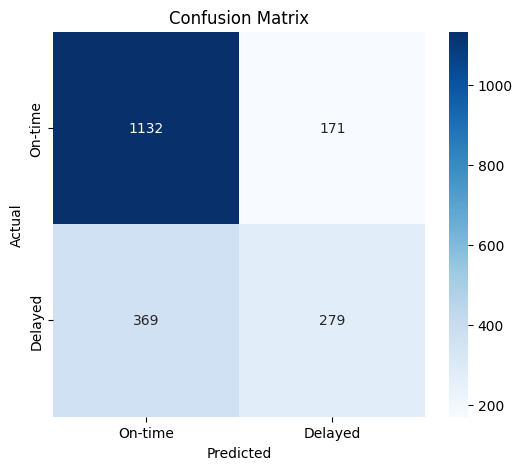

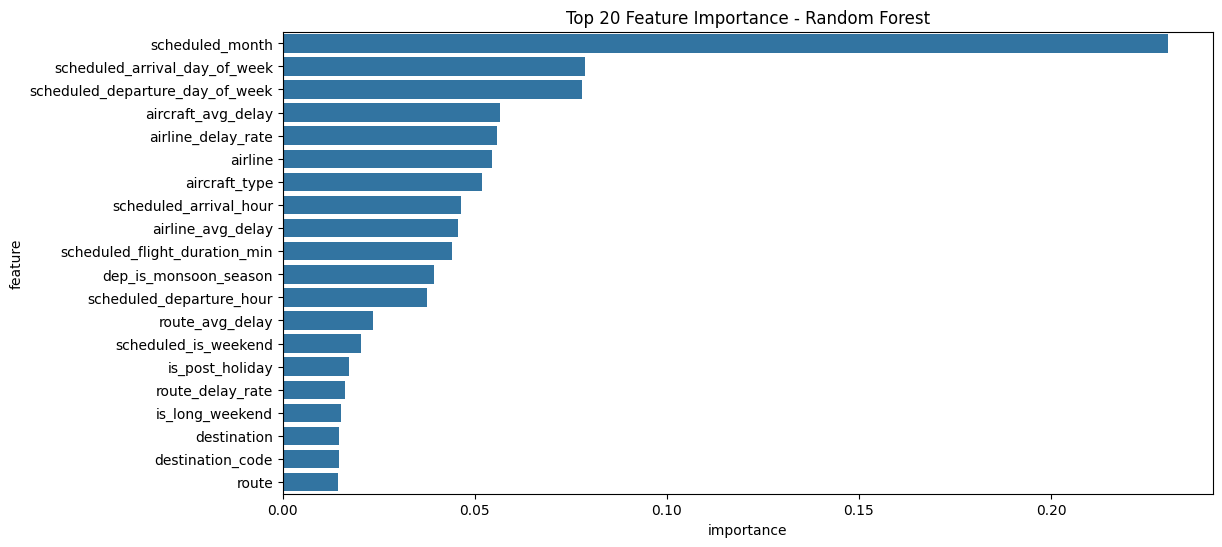

In [136]:
# # =============================
# # Flight Delay Prediction Script
# # =============================

# # 1️⃣ Import Libraries
# import pandas as pd
# import numpy as np
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import LabelEncoder
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# import xgboost as xgb
# import matplotlib.pyplot as plt
# import seaborn as sns

# # 2️⃣ Load Data
# # Replace 'flights.csv' with your dataset path
# df = pd.read_csv("flights.csv")
# Step 1: Imports and Data Load
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_absolute_error,accuracy_score, mean_squared_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression
import xgboost as xgb
import joblib
import warnings
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)
warnings.filterwarnings('ignore')

# Load the dataset (update path if needed)
df = pd.read_csv('../data/Original_Flight_Data.csv')
print("Shape of dataset (rows, columns):")
# print("Dataset shape:", df.shape)

# print("\nColumn names:")
# print(df.columns.tolist())

# print("\nFirst 5 rows:")
# display(df.head())

# print("\nDataset info:")
# df.info()

# print("\nStatistical summary (numeric columns):")
# display(df.describe())
print("Dataset loaded successfully!")

drop_cols = [
    'id', 'dep_date_only',
    'actual_depature_time', 'actual_arrival_time', 
    'dep_has_rain', 'dep_has_thunderstorm', 'dep_low_visibility', 'dep_high_wind',
    'arr_has_rain', 'arr_has_thunderstorm', 'arr_low_visibility',
    'binary_delay_arr', 'delay_class_dep', 'delay_class_arr',
    'departure_delay_min', 'arrival_delay_min', 'delay_ratio',
    'is_diverted', 'is_cancelled'
]
df = df.drop(columns=drop_cols)

# 3️⃣ Encode categorical / object columns
categorical_cols = ['airline', 'destination', 'route', 'aircraft_type',
                    'origin', 'origin_code', 'destination_code',
                    'scheduled_departure_day_of_week', 'scheduled_arrival_day_of_week']

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

# 4️⃣ Convert time columns to numeric
for col in ['scheduled_depature_time', 'scheduled_arrival_time']:
    df[col] = pd.to_datetime(df[col], format='%H:%M', errors='coerce')
    df[col] = df[col].dt.hour * 60 + df[col].dt.minute
    df[col] = df[col].fillna(0)

# 5️⃣ Define Features and Target
X = df.drop(columns=['binary_delay_dep'])
y = df['binary_delay_dep']

# 6️⃣ Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 7️⃣ Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=1000,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# 8️⃣ Predictions
y_pred = rf_model.predict(X_test)

# 9️⃣ Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['On-time','Delayed'], yticklabels=['On-time','Delayed'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Feature Importance
importances = rf_model.feature_importances_
feat_names = X.columns
feat_importance_df = pd.DataFrame({'feature': feat_names, 'importance': importances})
feat_importance_df = feat_importance_df.sort_values(by='importance', ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x='importance', y='feature', data=feat_importance_df.head(20))
plt.title("Top 20 Feature Importance - Random Forest")
plt.show()


In [139]:
# Step 2: Cleaning & Prep
# Check for missing values
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 id                                   0
airline                              0
origin                               0
origin_code                          0
destination                          0
destination_code                     0
route                                0
aircraft_type                        0
scheduled_depature_time              0
actual_depature_time                 0
scheduled_arrival_time               0
actual_arrival_time                  0
departure_delay_min                  0
arrival_delay_min                    0
is_diverted                          0
is_cancelled                         0
dep_has_rain                         0
dep_has_thunderstorm                 0
dep_low_visibility                   0
dep_high_wind                        0
arr_has_rain                         0
arr_has_thunderstorm                 0
arr_low_visibility                   0
dep_is_monsoon_season                0
dep_date_only                        0
is_sri_l

In [98]:
# STEP 2: Handle missing values

# Drop actual times (not available at prediction)
df = df.drop(columns=['actual_depature_time', 'actual_arrival_time'])

# Fill weather flags (mostly empty) with 0
weather_cols = [
    'dep_has_rain', 'dep_has_thunderstorm', 'dep_low_visibility', 'dep_high_wind',
    'arr_has_rain', 'arr_has_thunderstorm', 'arr_low_visibility'
]
for col in weather_cols:
    if df[col].dtype == 'object':
        df[col] = df[col].replace(' ', 0)
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# Fill binary/indicator columns with 0
binary_cols = [
    'is_diverted', 'is_cancelled', 'is_sri_lankan_public_holiday',
    'is_poya_day', 'is_festival_period', 'is_post_holiday', 'is_long_weekend',
    'scheduled_is_weekend', 'scheduled_is_peak_hour',
    'scheduled_early_morning_departure', 'scheduled_late_night_departure',
    'is_short_haul', 'dep_is_monsoon_season',
    'binary_delay_dep', 'binary_delay_arr'
]
df[binary_cols] = df[binary_cols].fillna(0).astype(int)

# Fill numeric columns with 0
numeric_cols = [
    'scheduled_departure_hour', 'scheduled_arrival_hour', 'scheduled_month',
    'scheduled_flight_duration_min', 'delay_ratio',
    'route_avg_delay', 'route_delay_rate', 'airline_avg_delay', 'airline_delay_rate',
    'aircraft_avg_delay'
]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

# Fill categorical columns with 'Unknown'
categorical_cols = [
    'airline', 'origin', 'origin_code', 'destination', 'destination_code',
    'route', 'aircraft_type', 'scheduled_departure_day_of_week', 'scheduled_arrival_day_of_week'
]
df[categorical_cols] = df[categorical_cols].fillna('Unknown')


In [99]:
# STEP 3: Prepare features and targets

# Remove columns that leak target info
exclude_cols = ['id', 'departure_delay_min', 'arrival_delay_min',
                'binary_delay_dep', 'binary_delay_arr',
                'delay_class_dep', 'delay_class_arr',
                'actual_depature_time', 'actual_arrival_time', 'scheduled_depature_time', 
                'scheduled_arrival_time', 'dep_date_only']  # remove raw datetimes

# Build feature columns: include numeric, categorical, weather, and indicator columns
all_possible_features = numeric_cols + categorical_cols + weather_cols + [
    'is_sri_lankan_public_holiday', 'is_poya_day', 'is_festival_period',
    'is_post_holiday', 'is_long_weekend', 'dep_is_monsoon_season'
]

# Remove excluded columns
feature_cols = [col for col in all_possible_features if col not in exclude_cols]
X = df[feature_cols]

# Targets
y_binary = df['binary_delay_dep']
y_multi = df['delay_class_dep']

# Encode multiclass target
le = LabelEncoder()
y_multi_enc = le.fit_transform(y_multi)
print("Multiclass classes:", le.classes_)



Multiclass classes: ['Major' 'Minor' 'On-time']


In [100]:
# STEP 4: One-hot encode categorical features
# X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
# print("Final feature shape after encoding:", X.shape)

# STEP 4: Encode categorical features
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
print("Feature shape after encoding:", X.shape)


Feature shape after encoding: (9754, 77)


In [96]:
display(X.head())

,scheduled_departure_hour,scheduled_arrival_hour,scheduled_month,scheduled_flight_duration_min,route_avg_delay,route_delay_rate,airline_avg_delay,airline_delay_rate,aircraft_avg_delay,dep_has_rain,...,scheduled_departure_day_of_week_Sunday,scheduled_departure_day_of_week_Thursday,scheduled_departure_day_of_week_Tuesday,scheduled_departure_day_of_week_Wednesday,scheduled_arrival_day_of_week_Monday,scheduled_arrival_day_of_week_Saturday,scheduled_arrival_day_of_week_Sunday,scheduled_arrival_day_of_week_Thursday,scheduled_arrival_day_of_week_Tuesday,scheduled_arrival_day_of_week_Wednesday
0,23,2,12,150.0,19.124635,0.82668,20.330512,0.939428,14.247173,0.0,...,False,False,False,False,False,False,False,False,True,False
1,23,2,11,150.0,19.124635,0.82668,20.330512,0.939428,24.933135,0.0,...,True,False,False,False,True,False,False,False,False,False
2,8,10,11,120.0,19.124635,0.82668,20.330512,0.939428,14.247173,0.0,...,True,False,False,False,False,False,True,False,False,False
3,23,2,11,150.0,19.124635,0.82668,20.330512,0.939428,9.078422,0.0,...,False,False,False,False,False,False,True,False,False,False
4,23,2,11,150.0,19.124635,0.82668,20.330512,0.939428,18.181053,0.0,...,False,False,False,False,False,True,False,False,False,False


In [77]:
print(X.columns.tolist())

['scheduled_departure_hour', 'scheduled_arrival_hour', 'scheduled_month', 'scheduled_flight_duration_min', 'delay_ratio', 'route_avg_delay', 'route_delay_rate', 'airline_avg_delay', 'airline_delay_rate', 'aircraft_avg_delay', 'departure_delay_min', 'arrival_delay_min', 'dep_has_rain', 'dep_has_thunderstorm', 'dep_low_visibility', 'dep_high_wind', 'arr_has_rain', 'arr_has_thunderstorm', 'arr_low_visibility', 'is_sri_lankan_public_holiday', 'is_poya_day', 'is_festival_period', 'is_post_holiday', 'is_long_weekend', 'dep_is_monsoon_season', 'airline_Emirates', 'airline_FitsAir', 'airline_Gulf Air', 'airline_IndiGo', 'airline_SriLankan Airlines', 'airline_flydubai', 'destination_Chennai', 'destination_Delhi', 'destination_Dhaka', 'destination_Hyderabad', 'destination_Karachi', 'destination_Kathmandu', 'destination_Lahore', 'destination_Male', 'destination_Mumbai', 'destination_code_BOM', 'destination_code_DAC', 'destination_code_DEL', 'destination_code_HYD', 'destination_code_KHI', 'destina

In [101]:
# STEP 5: Train/test split
X_train, X_test, yb_train, yb_test, ym_train, ym_test = train_test_split(
    X, y_binary, y_multi_enc,
    test_size=0.2,
    random_state=42,
    stratify=y_binary
)



=== BINARY DELAY MODEL ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1303
           1       1.00      0.99      0.99       648

    accuracy                           1.00      1951
   macro avg       1.00      0.99      1.00      1951
weighted avg       1.00      1.00      1.00      1951

ROC-AUC: 0.9994291426243331


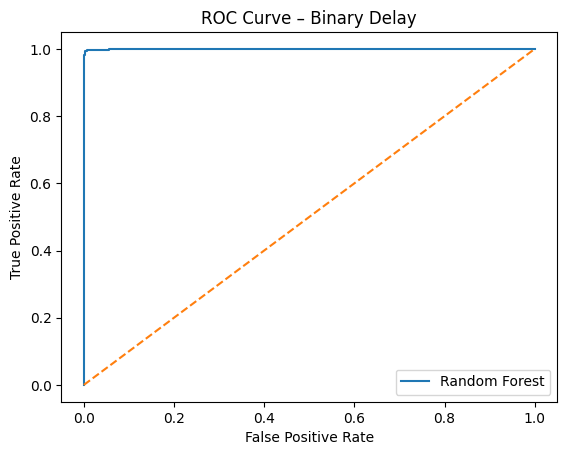

In [102]:
rf_binary = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    class_weight='balanced',
    random_state=42
)

rf_binary.fit(X_train, yb_train)

yb_pred = rf_binary.predict(X_test)
yb_prob = rf_binary.predict_proba(X_test)[:,1]

print("=== BINARY DELAY MODEL ===")
print(classification_report(yb_test, yb_pred))
print("ROC-AUC:", roc_auc_score(yb_test, yb_prob))

# ROC curve
fpr, tpr, _ = roc_curve(yb_test, yb_prob)
plt.plot(fpr, tpr, label='Random Forest')
plt.plot([0,1], [0,1], '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Binary Delay')
plt.legend()
plt.show()




=== MULTICLASS DELAY MODEL ===
              precision    recall  f1-score   support

       Major       0.97      0.38      0.55        95
       Minor       0.90      0.97      0.93       553
     On-time       0.99      1.00      0.99      1303

    accuracy                           0.96      1951
   macro avg       0.95      0.78      0.82      1951
weighted avg       0.96      0.96      0.95      1951



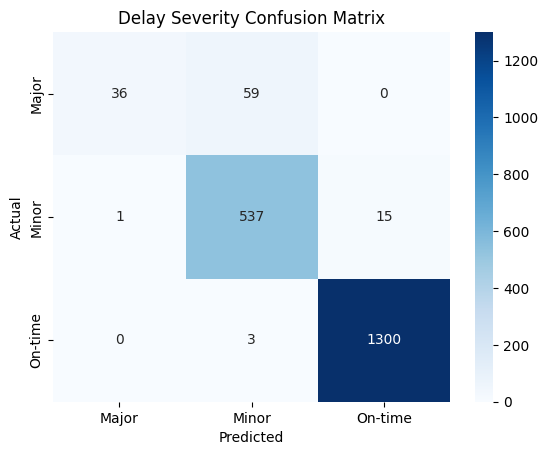

In [103]:
rf_multi = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    random_state=42
)

rf_multi.fit(X_train, ym_train)

ym_pred = rf_multi.predict(X_test)

print("=== MULTICLASS DELAY MODEL ===")
print(classification_report(ym_test, ym_pred, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(ym_test, ym_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Delay Severity Confusion Matrix")
plt.show()




In [104]:
sample = X_test.iloc[[0]]

binary_pred = rf_binary.predict(sample)[0]
binary_prob = rf_binary.predict_proba(sample)[0][1]

multi_pred = rf_multi.predict(sample)[0]
severity = le.inverse_transform([multi_pred])[0]

print("Binary Delay:", "Delayed" if binary_pred else "On-Time")
print("Delay Probability:", round(binary_prob, 2))
print("Delay Severity:", severity)

Binary Delay: On-Time
Delay Probability: 0.06
Delay Severity: On-time


In [111]:
from sklearn.metrics import accuracy_score

# Predict on test set
yb_pred = rf_binary.predict(X_test)

# Accuracy
binary_accuracy = accuracy_score(yb_test, yb_pred)
print("Binary Delay Model Accuracy:", round(binary_accuracy*100, 2), "%")


Binary Delay Model Accuracy: 99.59 %


In [112]:
from sklearn.metrics import accuracy_score

# Predict on test set
yb_pred = rf_binary.predict(X_test)

# Accuracy
binary_accuracy = accuracy_score(yb_test, yb_pred)
print("Binary Delay Model Accuracy:", round(binary_accuracy*100, 2), "%")

Binary Delay Model Accuracy: 99.59 %


In [84]:
# Predict on test set
ym_pred = rf_multi.predict(X_test)

# Accuracy
multi_accuracy = accuracy_score(ym_test, ym_pred)
print("Multiclass Delay Model Accuracy:", round(multi_accuracy*100, 2), "%")

Multiclass Delay Model Accuracy: 100.0 %


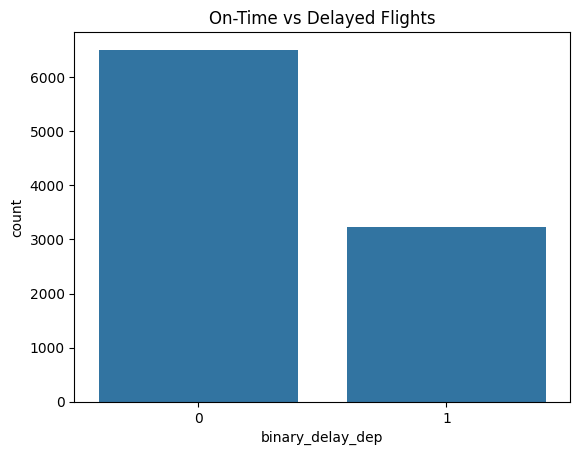

In [82]:
# Delay Distribution
sns.countplot(x='binary_delay_dep', data=df)
plt.title("On-Time vs Delayed Flights")
plt.show()

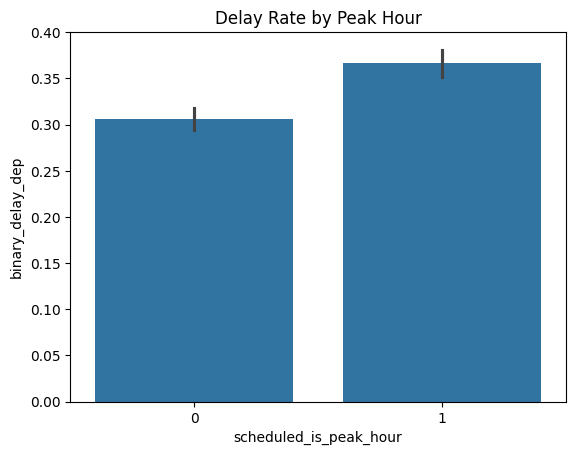

In [26]:
# Delay vs Peak Hour
sns.barplot(
    x='scheduled_is_peak_hour',
    y='binary_delay_dep',
    data=df
)
plt.title("Delay Rate by Peak Hour")
plt.show()

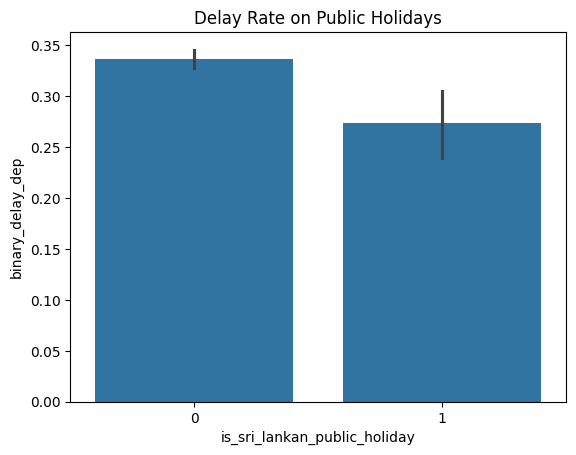

In [27]:
# Holiday Impact
sns.barplot(
    x='is_sri_lankan_public_holiday',
    y='binary_delay_dep',
    data=df
)
plt.title("Delay Rate on Public Holidays")
plt.show()

In [30]:
# Define Targets
y_binary = df['binary_delay_dep']
y_multi = df['delay_class_dep']

In [45]:
# Features (ONLY pre-flight data)
feature_cols = [
    'airline',
    'origin_code',
    'destination_code',
    'aircraft_type',

    'scheduled_departure_hour',
    'scheduled_departure_day_of_week',
    'scheduled_month',
    'scheduled_is_weekend',
    'scheduled_is_peak_hour',
    'scheduled_early_morning_departure',
    'scheduled_late_night_departure',
    'scheduled_flight_duration_min',

    'is_short_haul',
    'route_avg_delay',
    'route_delay_rate',
    'airline_avg_delay',
    'airline_delay_rate',
    'aircraft_avg_delay',

    'dep_has_rain',
    'dep_has_thunderstorm',
    'dep_low_visibility',
    'dep_high_wind',

    'is_sri_lankan_public_holiday',
    'is_poya_day',
    'is_festival_period',
    'is_post_holiday',
    'is_long_weekend',
    'dep_is_monsoon_season'
]

X = df[feature_cols]

In [46]:
# Handle Categorical Variables (One-Hot Encoding)
categorical_cols = [
    'airline',
    'origin_code',
    'destination_code',
    'aircraft_type',
    'scheduled_departure_day_of_week'
]

X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("Final Feature Count:", X.shape[1])

Final Feature Count: 53


In [47]:
# Encode Multiclass Target
le = LabelEncoder()
y_multi_enc = le.fit_transform(y_multi)

print("Delay Classes:", le.classes_)

Delay Classes: ['Major' 'Minor' 'On-time']


In [48]:
# Train / Test Split (Same Split for Both Models)
X_train, X_test, yb_train, yb_test, ym_train, ym_test = train_test_split(
    X, y_binary, y_multi_enc,
    test_size=0.2,
    random_state=42,
    stratify=y_binary
)

In [50]:
empty_cols = X.columns[(X == ' ').any() | (X.isna()).any()]
print("Columns with empty or missing values:", empty_cols.tolist())

Columns with empty or missing values: ['dep_low_visibility', 'dep_high_wind']


In [56]:
df[['dep_low_visibility', 'dep_high_wind']].isna().sum()

dep_low_visibility    0
dep_high_wind         0
dtype: int64

In [57]:
for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = X[col].replace(' ', 'Unknown')
    else:
        X[col] = pd.to_numeric(X[col], errors='coerce').fillna(0)


In [58]:
print(X.isna().sum().sum())  # should be 0
print((X == ' ').sum().sum())  # should be 0

0
0


In [59]:
# Check for columns with empty strings
empty_cols = X.columns[(X == ' ').any() | (X.isna()).any()]
print("Columns with empty or missing values:", empty_cols.tolist())

Columns with empty or missing values: []


In [61]:
# 1️⃣ Define categorical & numeric
categorical_cols = [
    'airline', 'origin_code', 'destination_code', 
    'aircraft_type', 'scheduled_departure_day_of_week'
]

numeric_cols = [col for col in X.columns if col not in categorical_cols]

# 2️⃣ Fill missing
X[numeric_cols] = X[numeric_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
X[categorical_cols] = X[categorical_cols].fillna('Unknown')  # still strings, will be encoded

# 3️⃣ One-hot encode categorical columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# 4️⃣ Check final matrix
print(X.head())
print("Shape after encoding:", X.shape)

KeyError: "None of [Index(['airline', 'origin_code', 'destination_code', 'aircraft_type',\n       'scheduled_departure_day_of_week'],\n      dtype='object')] are in the [columns]"

In [60]:
X_train, X_test, yb_train, yb_test, ym_train, ym_test = train_test_split(
    X, y_binary, y_multi_enc,
    test_size=0.2,
    random_state=42,
    stratify=y_binary
)

rf_binary.fit(X_train, yb_train)
rf_multi.fit(X_train, ym_train)


ValueError: could not convert string to float: 'Unknown'

In [49]:
# Train Binary Random Forest
rf_binary = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    class_weight='balanced',
    random_state=42
)

rf_binary.fit(X_train, yb_train)

ValueError: could not convert string to float: ' '

In [ ]:
Evaluate Binary Model
yb_pred = rf_binary.predict(X_test)
yb_prob = rf_binary.predict_proba(X_test)[:, 1]

print("BINARY DELAY MODEL")
print(classification_report(yb_test, yb_pred))
print("ROC-AUC:", roc_auc_score(yb_test, yb_prob))

In [5]:
# Convert datetime columns (handles MM/DD/YYYY format)
df['scheduled_departure'] = pd.to_datetime(df['scheduled_departure'])
df['actual_departure'] = pd.to_datetime(df['actual_departure'])
df['scheduled_arrival'] = pd.to_datetime(df['scheduled_arrival'])
df['actual_arrival'] = pd.to_datetime(df['actual_arrival'])

In [6]:
# Encode categoricals (one-hot for airline, destination, day_of_week)
df_encoded = pd.get_dummies(df, columns=['airline', 'destination', 'day_of_week'], drop_first=True)

In [7]:
# Features list (exclude targets and IDs; keep datetimes for now - we'll drop later if needed)
feature_cols = [col for col in df_encoded.columns if col not in ['flight_id', 'actual_departure', 'actual_arrival',
                                                                'delay_minutes_departure', 'delay_minutes_arrival']]
target = 'delay_minutes_departure'

print("Encoded Shape:", df_encoded.shape)
print("Feature Columns (top 10):", feature_cols[:10])
print("\nSample Encoded Row (first row, key columns):")
print(df_encoded.iloc[0][['inbound_delay_min', 'dep_has_thunderstorm', 'day_of_week_Sunday', target]].to_dict())

Encoded Shape: (7000, 37)
Feature Columns (top 10): ['origin', 'scheduled_departure', 'scheduled_arrival', 'inbound_delay_min', 'dep_has_thunderstorm', 'arr_has_thunderstorm', 'dep_has_crosswind', 'arr_has_low_visibility', 'is_post_poya_or_festival', 'is_night_push']

Sample Encoded Row (first row, key columns):
{'inbound_delay_min': 15, 'dep_has_thunderstorm': 0, 'day_of_week_Sunday': True, 'delay_minutes_departure': 1}


In [12]:
# Step 3: Feature Creation
# Add dep_hour (time of day effect)
df_encoded['dep_hour'] = df_encoded['scheduled_departure'].dt.hour

In [13]:
# Add total_weather_risk (sum of weather flags)
weather_flags = ['dep_has_thunderstorm', 'arr_has_thunderstorm', 'dep_has_crosswind', 'arr_has_low_visibility']
df_encoded['total_weather_risk'] = df_encoded[weather_flags].sum(axis=1)

In [15]:
# Update feature list
feature_cols = [col for col in df_encoded.columns if col not in ['flight_id', 'actual_departure', 'actual_arrival', 
                                                                'delay_minutes_departure', 'delay_minutes_arrival',
                                                                'scheduled_departure', 'scheduled_arrival']]  # Drop raw datetimes

print("New Features Added:", ['dep_hour', 'total_weather_risk'])
print("Updated Feature Count:", len(feature_cols))
print("\nEnhanced Dataset Head:")
print(df_encoded[['delay_minutes_departure', 'dep_hour', 'total_weather_risk']].head())

New Features Added: ['dep_hour', 'total_weather_risk']
Updated Feature Count: 32

Enhanced Dataset Head:
   delay_minutes_departure  dep_hour  total_weather_risk
0                        1        15                   0
1                        3        17                   0
2                        2        19                   0
3                        0         5                   0
4                        9        13                   1


In [16]:
# Step 4: Feature Selection
# Prepare X, y
X = df_encoded[feature_cols]
y = df_encoded[target]

In [18]:
# FIX: Filter to numeric columns only (drops 'origin', datetimes if object)
X = X.select_dtypes(include=[np.number])

print("Numeric X Shape (after filter):", X.shape)
print("Numeric Feature Columns (all):", X.columns.tolist())

Numeric X Shape (after filter): (7000, 13)
Numeric Feature Columns (all): ['inbound_delay_min', 'dep_has_thunderstorm', 'arr_has_thunderstorm', 'dep_has_crosswind', 'arr_has_low_visibility', 'is_post_poya_or_festival', 'is_night_push', 'cmb_runway_closed', 'indian_atc_gdp_active', 'airport_congestion_score', 'is_monsoon_season', 'dep_hour', 'total_weather_risk']


In [19]:
# Now select top 15 (safe, all numeric)
selector = SelectKBest(score_func=f_regression, k=min(15, X.shape[1]))  # min() handles if <15 cols
X_selected = selector.fit_transform(X, y)
selected_features = X.columns[selector.get_support(indices=True)].tolist()  # Use X.columns now

print("Top Selected Features:", selected_features)
print("Selection Scores (top 5):", sorted(selector.scores_, reverse=True)[:5])

Top Selected Features: ['inbound_delay_min', 'dep_has_thunderstorm', 'arr_has_thunderstorm', 'dep_has_crosswind', 'arr_has_low_visibility', 'is_post_poya_or_festival', 'is_night_push', 'cmb_runway_closed', 'indian_atc_gdp_active', 'airport_congestion_score', 'is_monsoon_season', 'dep_hour', 'total_weather_risk']
Selection Scores (top 5): [np.float64(48.636687633725515), np.float64(5.754971902036321), np.float64(4.341041565612074), np.float64(4.130094592472565), np.float64(2.671866553008496)]


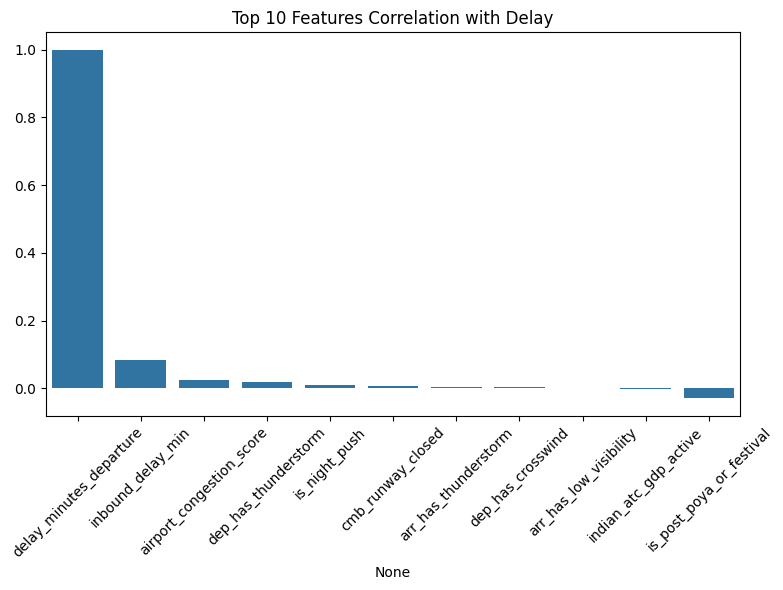

In [20]:
# Visualize correlation (top features vs target)
top_corr = pd.concat([X[selected_features[:10]], y], axis=1).corr()[target].sort_values(ascending=False)
plt.figure(figsize=(8, 6))
sns.barplot(x=top_corr.index, y=top_corr.values)
plt.title('Top 10 Features Correlation with Delay')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
# Update X to selected (for training)
X = pd.DataFrame(X_selected, columns=selected_features)
print("Final X Shape for Training:", X.shape)

Final X Shape for Training: (7000, 13)


In [24]:
# Step 5: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train Shape:", X_train.shape, y_train.shape)
print("Test Shape:", X_test.shape, y_test.shape)

Train Shape: (5600, 13) (5600,)
Test Shape: (1400, 13) (1400,)


In [41]:
# Step 6: Train Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

NameError: name 'y_train' is not defined

In [26]:
# Quick train prediction
y_train_pred = rf_model.predict(X_train)
print("Random Forest Train R²:", r2_score(y_train, y_train_pred))

Random Forest Train R²: 0.6755972813144864


In [27]:
# Step 7: Train XGBoost
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [28]:
# Quick train prediction
y_train_pred_xgb = xgb_model.predict(X_train)
print("XGBoost Train R²:", r2_score(y_train, y_train_pred_xgb))

XGBoost Train R²: 0.24950635433197021


In [29]:
# Step 8: Evaluation
# Random Forest Test
y_test_pred_rf = rf_model.predict(X_test)
mae_rf = mean_absolute_error(y_test, y_test_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))
r2_rf = r2_score(y_test, y_test_pred_rf)

In [30]:
# XGBoost Test
y_test_pred_xgb = xgb_model.predict(X_test)
mae_xgb = mean_absolute_error(y_test, y_test_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_test_pred_xgb))
r2_xgb = r2_score(y_test, y_test_pred_xgb)

In [31]:
# Print Metrics
print("Random Forest - MAE:", mae_rf, "| RMSE:", rmse_rf, "| R²:", r2_rf)
print("XGBoost - MAE:", mae_xgb, "| RMSE:", rmse_xgb, "| R²:", r2_xgb)

Random Forest - MAE: 10.578561618271895 | RMSE: 16.747530020269206 | R²: -0.17906142659758273
XGBoost - MAE: 9.572537422180176 | RMSE: 15.931377117357707 | R²: -0.06694376468658447


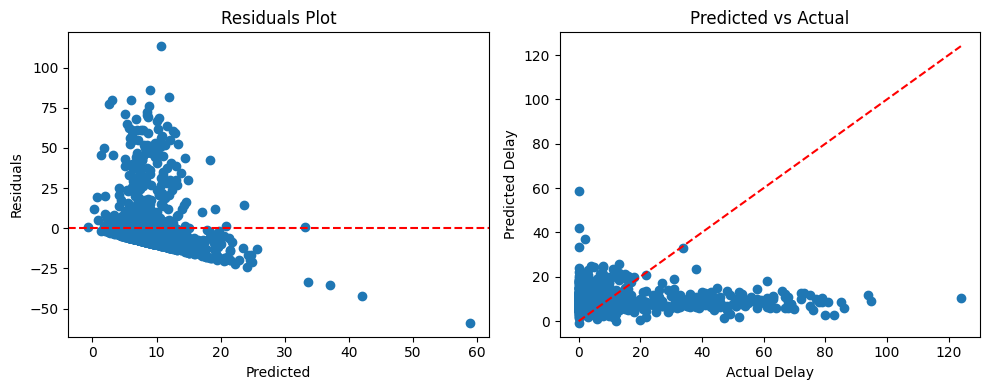

In [33]:
# Plot residuals (for XGBoost, best model)
residuals = y_test - y_test_pred_xgb
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(y_test_pred_xgb, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals Plot')
plt.xlabel('Predicted')
plt.ylabel('Residuals')

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_test_pred_xgb)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Predicted vs Actual')
plt.xlabel('Actual Delay')
plt.ylabel('Predicted Delay')
plt.tight_layout()
plt.show()